# homework 1.3: QR decomposition and least squares

**name:** Aashir  
**course:** MAT 422, Fall 2026  
**topics:** QR decomposition, least-squares problems, and linear regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aaxhirrr/mat-422-fall-2026/blob/AASHIR/hw1-3/HW1.3/HW1_3_least_squares.ipynb)

We start with a small matrix, factor it using QR, and use those factors to solve a least-squares problem. Then we fit a line to a few sample points and look at the errors.

## setup

The calculations use NumPy and the plots use Matplotlib. Run the cells from top to bottom. Both libraries are already available in Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 4.5), "font.size": 11})

## 1.3.1 QR decomposition

QR decomposition writes a matrix as $A=QR$. The columns of $Q$ are orthonormal, and $R$ is upper triangular. The entries of $R$ tell us how to combine the columns of $Q$ to get the original columns of $A$. This connects to the orthonormal basis from Gram-Schmidt in the last homework.

I chose this matrix because its two columns are independent and the numbers are easy to follow:

$$
A=\begin{bmatrix}1&0\\1&1\\1&2\end{bmatrix}.
$$

We use reduced QR, so $Q$ has size $3\times2$ and $R$ has size $2\times2$. The checks are $Q^TQ=I_2$, zeros below the diagonal of $R$, and $QR=A$. Since $Q$ is rectangular, $QQ^T$ is a projection matrix, not the $3\times3$ identity.

In [2]:
A = np.array([
    [1.0, 0.0],
    [1.0, 1.0],
    [1.0, 2.0],
])

Q, R = np.linalg.qr(A, mode="reduced")

print("Q =\n", Q)
print("\nR =\n", R)
print("\nQ shape:", Q.shape, "R shape:", R.shape)
print("\nQ.T @ Q =\n", Q.T @ Q)
print("\nQ @ R =\n", Q @ R)

# these checks are easier to read than comparing every entry by hand
assert np.linalg.matrix_rank(A) == 2
assert np.allclose(Q.T @ Q, np.eye(2))
assert np.allclose(R, np.triu(R))
assert np.allclose(Q @ R, A)

Q =
 [[-0.5774  0.7071]
 [-0.5774  0.    ]
 [-0.5774 -0.7071]]

R =
 [[-1.7321 -1.7321]
 [ 0.     -1.4142]]

Q shape: (3, 2) R shape: (2, 2)

Q.T @ Q =
 [[1. 0.]
 [0. 1.]]

Q @ R =
 [[1. 0.]
 [1. 1.]
 [1. 2.]]


The product $QR$ gives the original matrix, and $Q^TQ$ is the identity up to rounding. Its diagonal entries are one because each column has length one. The off-diagonal entries are zero because the columns are perpendicular.

The zero below the diagonal of $R$ confirms its triangular form. Signs in $Q$ and $R$ can differ between implementations, but matching sign changes still give the same product $QR$.

## 1.3.2 least-squares problems

Now we keep the same $A$ and try to solve $Ac=b$ with $b=(1,2,2)^T$. There are three equations and only two unknowns. The first two equations would give $c_0=1$ and $c_1=1$, but then the third gives $3$ instead of $2$. An exact solution does not exist here.

Least squares finds coefficients that minimize the sum of squared errors:

$$
\hat c=\operatorname*{arg\,min}_{c}\|b-Ac\|_2^2.
$$

The fitted vector $A\hat c$ is the projection of $b$ onto the column space of $A$. The residual $r=b-A\hat c$ is perpendicular to that space, so $A^Tr=0$. Rearranging gives the normal equations:

$$
A^TA\hat c=A^Tb.
$$

Using the QR factors, the coefficients satisfy $R\hat c=Q^Tb$. The columns of $A$ are independent, so $R$ is invertible and the solution is unique. We use `solve` for this small system and compare the answer with `lstsq`.

In [3]:
b = np.array([1.0, 2.0, 2.0])

# reuse the QR factors from the previous section
coefficients = np.linalg.solve(R, Q.T @ b)
fitted = A @ coefficients
residual = b - fitted
squared_error = np.sum(residual ** 2)
numpy_coefficients = np.linalg.lstsq(A, b, rcond=None)[0]

print("coefficients =", coefficients)
print("fitted values =", fitted)
print("residual =", residual)
print(f"sum of squared errors = {squared_error:.6f}")
print("A.T @ residual =", A.T @ residual)
print("NumPy least-squares answer =", numpy_coefficients)

assert np.allclose(coefficients, [7 / 6, 0.5])
assert np.allclose(coefficients, numpy_coefficients)
assert np.allclose(A.T @ residual, np.zeros(2))
assert np.isclose(squared_error, 1 / 6)

coefficients = [1.1667 0.5   ]
fitted values = [1.1667 1.6667 2.1667]
residual = [-0.1667  0.3333 -0.1667]
sum of squared errors = 0.166667
A.T @ residual = [0. 0.]
NumPy least-squares answer = [1.1667 0.5   ]


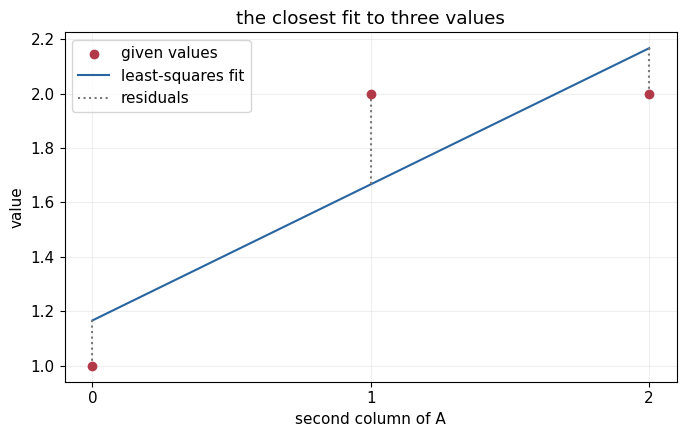

In [4]:
positions = A[:, 1]

fig, ax = plt.subplots()
ax.scatter(positions, b, color="#b23a48", label="given values", zorder=3)
ax.plot(positions, fitted, color="#2864a0", label="least-squares fit")

# the dotted gaps show what the line misses at each point
ax.vlines(positions, fitted, b, color="#777777", linestyle="dotted",
          label="residuals")
ax.set(xlabel="second column of A", ylabel="value",
       title="the closest fit to three values")
ax.set_xticks(positions)
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

We get $\hat c=(7/6,1/2)^T$, or about $(1.1667,0.5)^T$. The residual is $(-1/6,1/3,-1/6)^T$, and the squared errors add up to $1/6\approx0.1667$. The line misses each point a little, but that is expected because the three equations cannot all hold at once.

The check $A^Tr\approx0$ shows that the residual is perpendicular to both columns of $A$. This also explains why the answer minimizes the error. For any coefficient change $d$,

$$
\|b-A(\hat c+d)\|_2^2=\|r\|_2^2+\|Ad\|_2^2\geq\|r\|_2^2.
$$

The cross term is zero because $r$ is perpendicular to $Ad$. Changing the coefficients cannot make the squared error smaller.

## 1.3.3 linear regression

Linear regression uses the same least-squares idea to fit a relationship between variables. Here the model is

$$
\hat y=\beta_0+\beta_1 x,
$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope. I used six made-up pairs of study hours and quiz scores so we can see the calculation without loading a dataset. These are example values, not records from real students.

Each row of the design matrix $X$ is $[1,x_i]$. The column of ones lets the model include an intercept. We solve $\min_\beta\|y-X\beta\|_2^2$ and then calculate a predicted score at 4.5 hours.

In [5]:
hours = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
scores = np.array([52.0, 55.0, 61.0, 64.0, 68.0, 73.0])

# the first column is for the intercept, the second is for hours
X = np.column_stack((np.ones(len(hours)), hours))
beta = np.linalg.lstsq(X, scores, rcond=None)[0]
intercept, slope = beta
predicted_scores = X @ beta
score_residuals = scores - predicted_scores

new_hours = 4.5
new_score = intercept + slope * new_hours

print(f"fitted line: score = {intercept:.4f} + {slope:.4f} * hours")
print(f"prediction at {new_hours} hours = {new_score:.4f}")
print("\n hours  actual  fitted  residual")
for h, actual, predicted, error in zip(hours, scores, predicted_scores, score_residuals):
    print(f"{h:6.1f} {actual:7.1f} {predicted:7.2f} {error:9.2f}")

assert np.allclose(beta, [47.4666666667, 4.2])
assert np.allclose(X.T @ score_residuals, np.zeros(2))

fitted line: score = 47.4667 + 4.2000 * hours
prediction at 4.5 hours = 66.3667

 hours  actual  fitted  residual
   1.0    52.0   51.67      0.33
   2.0    55.0   55.87     -0.87
   3.0    61.0   60.07      0.93
   4.0    64.0   64.27     -0.27
   5.0    68.0   68.47     -0.47
   6.0    73.0   72.67      0.33


The fitted line is $\hat y\approx47.4667+4.2x$. In this example, one additional study hour corresponds to 4.2 more points on the fitted line. At 4.5 hours, the predicted score is about 66.37. This is within the observed range of 1 to 6 hours.

The intercept is the model's prediction at zero hours, but zero is outside this dataset. We should not treat it as a measured score or use these made-up points to claim that studying causes a particular score increase.

To describe the fit, we calculate the sum of squared errors (SSE), the root mean squared error (RMSE), and $R^2$:

$$
\mathrm{SSE}=\sum_i(y_i-\hat y_i)^2,\qquad
\mathrm{RMSE}=\sqrt{\mathrm{SSE}/n},\qquad
R^2=1-\frac{\mathrm{SSE}}{\sum_i(y_i-\bar y)^2}.
$$

RMSE is in score points. $R^2$ compares the fitted line with using the mean score for every observation.

In [6]:
sse = np.sum(score_residuals ** 2)
rmse = np.sqrt(sse / len(scores))
mean_error = np.sum((scores - np.mean(scores)) ** 2)
r_squared = 1 - sse / mean_error

print(f"sum of squared errors = {sse:.4f}")
print(f"RMSE = {rmse:.4f} score points")
print(f"R squared = {r_squared:.4f}")
print(f"mean-only squared error = {mean_error:.4f}")

assert sse < mean_error
assert np.isclose(np.sum(score_residuals), 0.0)

sum of squared errors = 2.1333
RMSE = 0.5963 score points
R squared = 0.9931
mean-only squared error = 310.8333


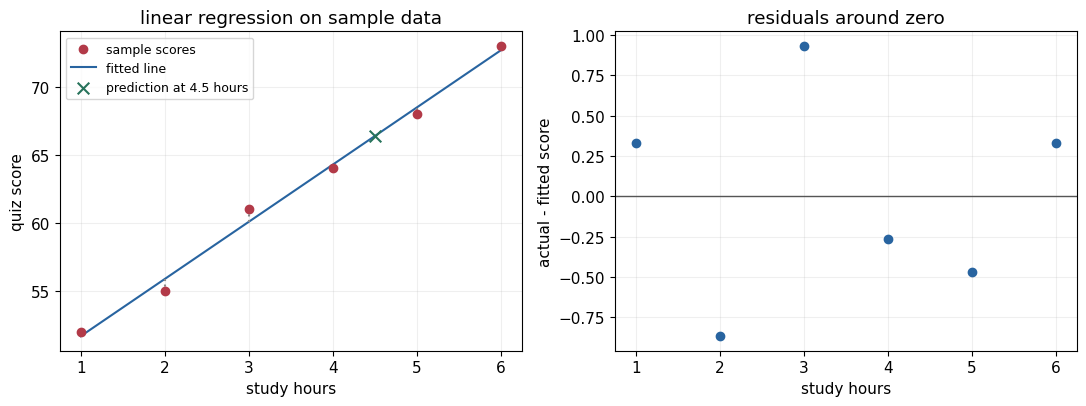

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(hours, scores, color="#b23a48", label="sample scores", zorder=3)
axes[0].plot(hours, predicted_scores, color="#2864a0", label="fitted line")
axes[0].vlines(hours, predicted_scores, scores, color="#888888",
               linestyle="dotted")
axes[0].scatter(new_hours, new_score, marker="x", s=70, color="#27735b",
                label="prediction at 4.5 hours", zorder=4)
axes[0].set(xlabel="study hours", ylabel="quiz score",
            title="linear regression on sample data")
axes[0].legend(fontsize=9)

# looking at the misses separately makes them easier to compare
axes[1].scatter(hours, score_residuals, color="#2864a0", zorder=3)
axes[1].axhline(0, color="#555555", linewidth=1)
axes[1].set(xlabel="study hours", ylabel="actual - fitted score",
            title="residuals around zero")

for ax in axes:
    ax.set_xticks(hours)
    ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

The RMSE is about 0.5963 score points, and $R^2\approx0.9931$. The line reduces the squared error by about 99.31% compared with predicting the mean score for all six points. In the residual plot, some scores are above the line and others are below it. Their residuals sum to approximately zero because the least-squares model includes an intercept.

This is a close fit to these six example points. It does not tell us how well the model would predict scores for new students. We would need separate data to check that.

## final checks

These collect the main checks from the notebook. Each one should print `True`.

In [8]:
checks = {
    "Q has orthonormal columns": np.allclose(Q.T @ Q, np.eye(2)),
    "R is upper triangular": np.allclose(R, np.triu(R)),
    "QR reconstructs A": np.allclose(Q @ R, A),
    "QR and least squares agree": np.allclose(coefficients, numpy_coefficients),
    "least-squares residual is orthogonal": np.allclose(A.T @ residual, 0),
    "regression residual is orthogonal": np.allclose(X.T @ score_residuals, 0),
    "line improves on the mean prediction": sse < mean_error,
}

for name, passed in checks.items():
    print(f"{name}: {passed}")

assert all(checks.values())

Q has orthonormal columns: True
R is upper triangular: True
QR reconstructs A: True
QR and least squares agree: True
least-squares residual is orthogonal: True
regression residual is orthogonal: True
line improves on the mean prediction: True


## conclusion

QR gave us an orthonormal basis and a triangular system that was easy to solve. When the three equations did not have an exact solution, least squares found the closest fitted vector and left a residual perpendicular to the columns of $A$. I used that same idea to fit a line to the sample scores. The slope, prediction, and residuals show what the fitted line does, while the fit measures describe its errors on the points we actually used.

## notes and references

- Ren, J., and Wang, H. (2023). *Mathematical Methods in Data Science*. Elsevier.
- NumPy documentation: [QR decomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html) and [least squares](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html).
- The study hours and quiz scores are made-up values for this example. Matplotlib was used for the figures.

- AI use note: I had help from Codex in refining the code (not completely writing it), refining the latex of the report, and pushing it to GitHub. Other than that, the intial psuedocode/boilerplates, logic, and the report is still drafted by me. I ran every cell and reviewed the math and explanations before submitting.